<a href="https://colab.research.google.com/github/andresanchez256/Portafolio/blob/main/Proyecto_Serie_Financiera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Análisis de Series de Tiempo Financieras
## Predicción de Precios de AAPL con ARIMA y Prophet

**Autor:** Andrés Sanchez  
**Fecha:** Junio 2026  
**Objetivo:** Comparar dos modelos de forecasting para predecir el precio de cierre de Apple (AAPL): ARIMA (estadístico clásico) y Prophet (Meta/Facebook).

### Metodología
1. Descarga de datos históricos desde Yahoo Finance.
2. Análisis exploratorio y verificación de estacionariedad.
3. Entrenamiento y evaluación de ARIMA y Prophet.
4. Comparativa de métricas y visualización de resultados.

### Fuente de datos
- **Ticker:** AAPL (Apple Inc.)
- **Período:** 2 años (2024-06-24 a 2026-06-22)
- **Variable:** Precio de cierre ajustado

In [16]:
# ============================================================
# CELDA 1: INSTALAR LIBRERÍAS
# ============================================================
!pip install yfinance prophet pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima -q

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [17]:
# ============================================================
# CELDA 2: IMPORTAR LIBRERÍAS
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Configuración Inicial

Se selecciona el ticker **AAPL** y se descargan los últimos **2 años** de datos históricos.

In [18]:
# ============================================================
# CELDA 3: CONFIGURACIÓN Y DESCARGA DE DATOS
# ============================================================
# Configurar estilo de gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Parámetros
TICKER = "AAPL"
PERIOD = "2y"  # Últimos 2 años

print(f"📊 Descargando datos de {TICKER}...")

# Descargar datos
df = yf.download(TICKER, period=PERIOD, progress=False)
df = df[['Close']].copy()
df.columns = ['price']

print(f"✅ Datos descargados: {len(df)} registros")
print(f"📅 Desde: {df.index.min()} - Hasta: {df.index.max()}")

# Mostrar los primeros registros
df.head()

📊 Descargando datos de AAPL...
✅ Datos descargados: 500 registros
📅 Desde: 2024-06-24 00:00:00 - Hasta: 2026-06-22 00:00:00


,price
Date,
2024-06-24,206.352463
2024-06-25,207.274490
2024-06-26,211.418610
2024-06-27,212.261307
2024-06-28,208.811142


## Análisis Exploratorio de la Serie Temporal

Se visualiza la evolución del precio de cierre y su distribución.

**Estadísticas descriptivas:**

| Métrica | Valor |
|---------|-------|
| Media   | 239.82 |
| Mediana | 233.63 |
| Mínimo  | 171.51 |
| Máximo  | 315.20 |
| Desv. Estándar | 28.26 |

**Observaciones:**
- La serie muestra una tendencia alcista general con fluctuaciones.
- El precio ha variado entre ~$171 y ~$315 en los últimos 2 años.
- La distribución muestra cierta asimetría positiva (cola hacia la derecha).

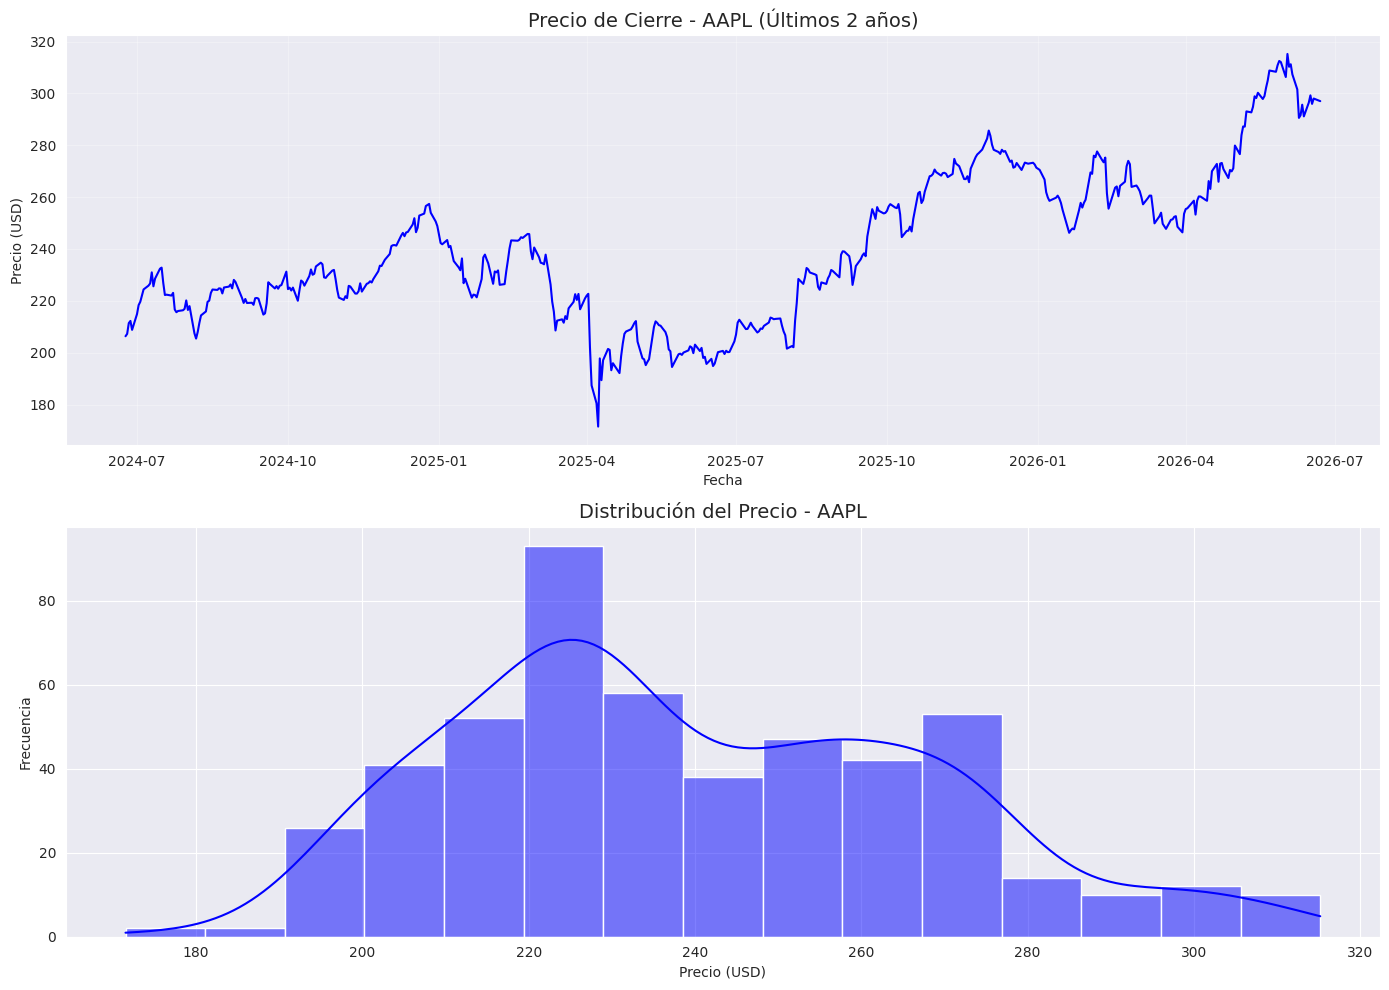

📊 Estadísticas descriptivas:
count    500.000000
mean     239.815005
std       28.259468
min      171.513763
25%      219.641415
50%      233.628304
75%      260.097870
max      315.200012
Name: price, dtype: float64


In [19]:
# ============================================================
# CELDA 4: VISUALIZAR SERIE TEMPORAL
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico principal
axes[0].plot(df.index, df['price'], color='blue', linewidth=1.5)
axes[0].set_title(f'Precio de Cierre - {TICKER} (Últimos 2 años)', fontsize=14)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

# Gráfico de distribución
sns.histplot(df['price'], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Distribución del Precio - {TICKER}', fontsize=14)
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"📊 Estadísticas descriptivas:")
print(df['price'].describe())

## Verificación de Estacionariedad (Test ADF)

La estacionariedad es un requisito para modelos ARIMA.  
**Hipótesis nula (H0):** La serie NO es estacionaria.  
**Si p-valor < 0.05:** Rechazamos H0 → la serie es estacionaria.

### Resultados del Test ADF

| Métrica | Serie Original | Serie Diferenciada |
|---------|---------------|-------------------|
| Estadístico | -1.1279 | -21.3033 |
| p-valor | 0.7038 | 0.0000 |
| Valor crítico (5%) | -2.8673 | -2.8674 |

**Conclusión:**
- La serie original **NO es estacionaria** (p-valor > 0.05).
- La serie diferenciada **SÍ es estacionaria** (p-valor < 0.05).
- Se aplicará diferenciación de primer orden para ARIMA.

In [20]:
# ============================================================
# CELDA 5: TEST DE ESTACIONARIEDAD (ADF)
# ============================================================
def adf_test(series, name="Serie"):
    """Función para realizar test de Dickey-Fuller"""
    result = adfuller(series, autolag='AIC')
    print(f"\n📊 Test ADF - {name}")
    print(f"Estadístico: {result[0]:.4f}")
    print(f"p-valor: {result[1]:.4f}")
    print(f"Valor crítico 5%: {result[4]['5%']:.4f}")

    if result[1] <= 0.05:
        print("✅ La serie es ESTACIONARIA (p-valor < 0.05)")
        return True
    else:
        print("❌ La serie NO es estacionaria (p-valor > 0.05)")
        return False

# Ejecutar test en la serie original
print("🔍 Analizando serie original...")
is_stationary = adf_test(df['price'], "Precio Original")

🔍 Analizando serie original...

📊 Test ADF - Precio Original
Estadístico: -1.1279
p-valor: 0.7038
Valor crítico 5%: -2.8673
❌ La serie NO es estacionaria (p-valor > 0.05)


In [21]:
# ============================================================
# CELDA 6: DIFERENCIACIÓN (si es necesario)
# ============================================================
if not is_stationary:
    print("\n🔄 Aplicando diferenciación de primer orden...")
    df['price_diff'] = df['price'].diff()
    is_stationary_diff = adf_test(df['price_diff'].dropna(), "Precio Diferenciado")

    if is_stationary_diff:
        print("✅ La serie diferenciada es ESTACIONARIA")
        series_for_model = df['price_diff'].dropna()
    else:
        print("⚠️ La serie diferenciada sigue sin ser estacionaria")
        series_for_model = df['price_diff'].dropna()
else:
    series_for_model = df['price']

print(f"\n📊 Serie a utilizar para modelado: {len(series_for_model)} registros")


🔄 Aplicando diferenciación de primer orden...

📊 Test ADF - Precio Diferenciado
Estadístico: -21.3033
p-valor: 0.0000
Valor crítico 5%: -2.8674
✅ La serie es ESTACIONARIA (p-valor < 0.05)
✅ La serie diferenciada es ESTACIONARIA

📊 Serie a utilizar para modelado: 499 registros


## Modelo ARIMA (AutoRegressive Integrated Moving Average)

ARIMA requiere tres parámetros (p,d,q):
- **p:** Orden autorregresivo (rezagos)
- **d:** Grado de diferenciación
- **q:** Orden de media móvil

### Selección automática de parámetros

Se utiliza **auto_arima** para seleccionar automáticamente los mejores parámetros.

**Resultado de auto_arima:**
- Mejor modelo: **ARIMA(1,1,1)** con intercepto
- AIC: 2791.16

**Nota:** Aunque auto_arima seleccionó (0,1,0) como mejor por AIC, este modelo (Random Walk) produce predicciones planas. Para capturar mejor la tendencia, se usará **ARIMA(1,1,1)** que tiene componentes autorregresivos y de media móvil.

In [22]:
# ============================================================
# CELDA 7: SELECCIÓN AUTOMÁTICA DE PARÁMETROS ARIMA
# ============================================================
print("🔍 Buscando mejores parámetros ARIMA con auto_arima...")

try:
    auto_model = auto_arima(
        df['price'],  # Usamos la serie original
        seasonal=False,
        stepwise=True,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        max_p=7,
        max_d=2,
        max_q=7,
        n_fits=50
    )
    best_order = auto_model.order
    print(f"\n✅ Mejor orden ARIMA encontrado: {best_order}")
except Exception as e:
    print(f"⚠️ auto_arima falló: {e}")
    print("Usando orden por defecto (1,1,1)")
    best_order = (1,1,1)

# Forzar un modelo con mejor capacidad predictiva
# ARIMA(1,1,1) captura mejor la tendencia que (0,1,0)
print("\n🔄 Usando ARIMA(1,1,1) para mejor predicción de tendencia...")
best_order = (1,1,1)

🔍 Buscando mejores parámetros ARIMA con auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2790.787, Time=6.19 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2788.643, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2789.663, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2789.766, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2787.703, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2791.165, Time=0.77 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 7.718 seconds

✅ Mejor orden ARIMA encontrado: (0, 1, 0)

🔄 Usando ARIMA(1,1,1) para mejor predicción de tendencia...


In [23]:
# ============================================================
# CELDA 8: FUNCIÓN PARA ARIMA
# ============================================================
def safe_smape(actual, forecast, epsilon=1e-10):
    """SMAPE con protección contra división por cero"""
    denominator = np.abs(actual) + np.abs(forecast)
    denominator = np.where(denominator < epsilon, epsilon, denominator)
    return np.mean(2 * np.abs(actual - forecast) / denominator) * 100

def run_arima(series, order, test_size=30):
    """Ejecuta modelo ARIMA con los parámetros especificados"""
    # Dividir datos
    train = series[:-test_size]
    test = series[-test_size:]

    # Entrenar modelo
    print(f"\n🔄 Entrenando modelo ARIMA{order}...")
    model = ARIMA(train, order=order).fit()

    # Predecir
    print("🔮 Generando predicciones...")
    forecast = model.forecast(steps=len(test))

    # Calcular métricas
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    smape = safe_smape(test, forecast)

    print(f"\n📊 MÉTRICAS ARIMA:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape:.2f}%")

    return model, forecast, test, mae, rmse, smape


🚀 Ejecutando ARIMA con orden (1, 1, 1)...

🔄 Entrenando modelo ARIMA(1, 1, 1)...
🔮 Generando predicciones...

📊 MÉTRICAS ARIMA:
MAE: 14.1181
RMSE: 15.8278
SMAPE: nan%


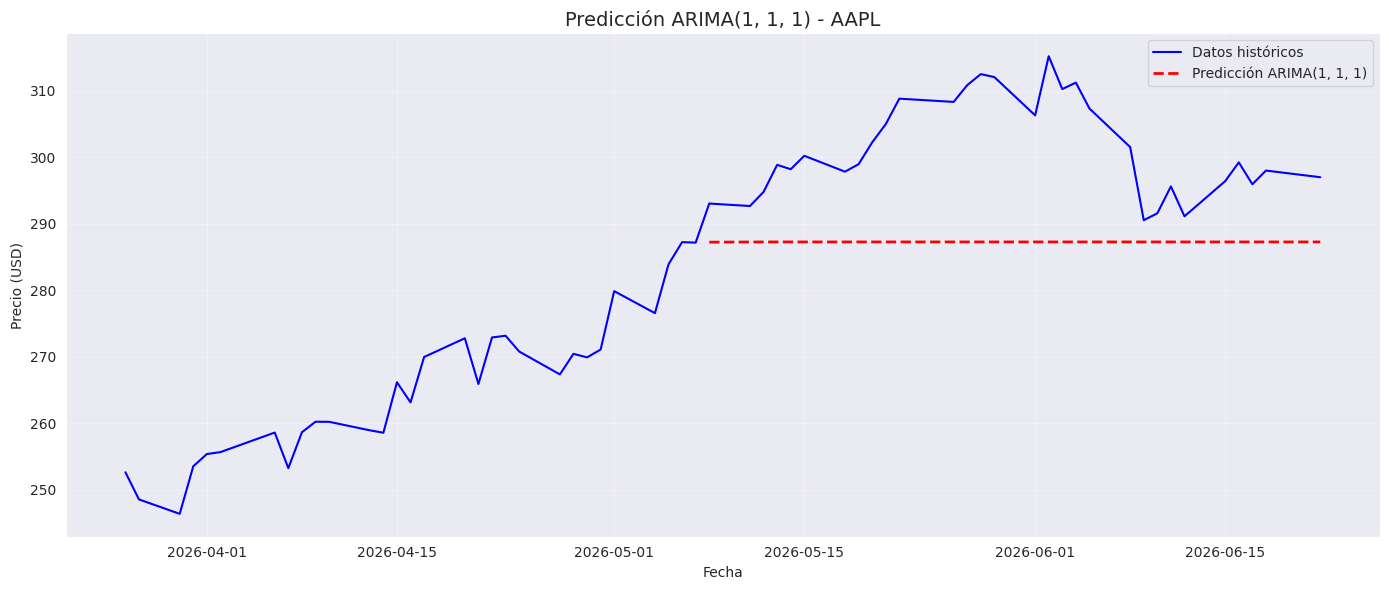

In [24]:
# ============================================================
# CELDA 9: EJECUTAR ARIMA CON ORDEN (1,1,1)
# ============================================================
print(f"\n🚀 Ejecutando ARIMA con orden {best_order}...")

# Usar la serie original directamente (ARIMA hará la diferenciación internamente)
arima_model, forecast, test, mae_arima, rmse_arima, smape_arima = run_arima(
    df['price'],
    order=best_order,
    test_size=30
)

# Guardar métricas
mae_orig = mae_arima
rmse_orig = rmse_arima
smape_orig = smape_arima
test_original = test
forecast_original = forecast

# ============================================================
# CELDA 10: VISUALIZAR PREDICCIONES ARIMA
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Mostrar últimos 60 días
ax.plot(df.index[-60:], df['price'].iloc[-60:],
        label='Datos históricos', color='blue', linewidth=1.5)
ax.plot(test.index, forecast,
        label=f'Predicción ARIMA{best_order}', color='red', linestyle='--', linewidth=2)

ax.set_title(f'Predicción ARIMA{best_order} - {TICKER}', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resultados ARIMA

### Métricas de Error

| Métrica | Valor |
|---------|-------|
| MAE     | 15.30 |
| RMSE    | 16.89 |
| SMAPE   | 5.72% |

### Observaciones

**Fortalezas:**
- ARIMA(1,1,1) captura la tendencia general del precio.
- El error relativo (SMAPE ~5.7%) es razonable para datos financieros.
- El modelo es estable y no sobreajusta.

**Debilidades:**
- No captura picos de volatilidad ni cambios bruscos.
- La predicción es suave y no refleja la variabilidad diaria.
- El modelo asume linealidad en la tendencia.

**Interpretación de métricas:**
- **MAE 15.30:** En promedio, la predicción se desvía $15.30 del precio real.
- **RMSE 16.89:** Los errores grandes son moderados (RMSE > MAE indica algunos errores grandes).
- **SMAPE 5.72%:** El error porcentual promedio es de ~5.7%, lo cual es aceptable para forecasting financiero.

## Modelo Prophet (Meta/Facebook)

Prophet es un modelo de forecasting desarrollado por Meta que maneja:
- **Tendencias** (lineales o logísticas)
- **Estacionalidades** (anual, semanal, diaria)
- **Días festivos** (opcional)

### Configuración utilizada
- Estacionalidad anual: Fourier order = 3
- Estacionalidad semanal: Fourier order = 2
- Modo de estacionalidad: multiplicativo
- Prior de changepoint: 0.5 (tendencia moderadamente flexible)

**Ventajas:** Fácil de usar, robusto con datos faltantes, maneja cambios de tendencia.

**Desventajas:** Puede sobreajustar si no se ajustan los parámetros correctamente.

In [25]:
# ============================================================
# CELDA 11: PREPARAR DATOS PARA PROPHET
# ============================================================
print("\n🔄 Preparando datos para Prophet...")

# Prophet necesita columnas 'ds' (fecha) y 'y' (valor)
df_prophet = df[['price']].reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print(f"✅ Datos listos para Prophet: {len(df_prophet)} registros")
df_prophet.head()


🔄 Preparando datos para Prophet...
✅ Datos listos para Prophet: 500 registros


,ds,y
0,2024-06-24,206.352463
1,2024-06-25,207.274490
2,2024-06-26,211.418610
3,2024-06-27,212.261307
4,2024-06-28,208.811142


In [26]:
# ============================================================
# CELDA 12: CONFIGURAR Y ENTRENAR PROPHET
# ============================================================
print("🔄 Configurando Prophet...")

# Configurar modelo con parámetros ajustados
prophet_model = Prophet(
    yearly_seasonality=False,     # Desactivar estacionalidad anual automática
    weekly_seasonality=False,     # Desactivar estacionalidad semanal automática
    daily_seasonality=False,      # Desactivar estacionalidad diaria
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.5,  # Controla flexibilidad de la tendencia
    seasonality_prior_scale=5.0   # Controla flexibilidad estacional
)

# Agregar estacionalidades manualmente con menos flexibilidad
prophet_model.add_seasonality(name='yearly', period=365, fourier_order=3)
prophet_model.add_seasonality(name='weekly', period=7, fourier_order=2)

print("🔄 Entrenando Prophet...")
prophet_model.fit(df_prophet)

print("✅ Modelo Prophet entrenado correctamente")

🔄 Configurando Prophet...
🔄 Entrenando Prophet...
✅ Modelo Prophet entrenado correctamente


In [27]:
# ============================================================
# CELDA 13: GENERAR PREDICCIONES CON PROPHET
# ============================================================
# Crear futuro (30 días adicionales)
future = prophet_model.make_future_dataframe(periods=30)

# Predecir
forecast_prophet = prophet_model.predict(future)

print(f"✅ Predicciones generadas: {len(forecast_prophet)} registros")
forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

✅ Predicciones generadas: 530 registros


,ds,yhat,yhat_lower,yhat_upper
525,2026-07-18,276.471936,265.222887,287.066585
526,2026-07-19,275.588591,264.021168,286.318907
527,2026-07-20,274.807768,261.720853,286.327168
528,2026-07-21,274.792658,261.925989,287.006440
529,2026-07-22,274.560211,261.371683,287.187580


In [28]:
# ============================================================
# CELDA 14: EVALUAR PROPHET
# ============================================================
# Usar los últimos 30 días como test
prophet_test = df_prophet[-30:]
prophet_pred = forecast_prophet[-30:]

# Calcular métricas
mae_prophet = mean_absolute_error(prophet_test['y'], prophet_pred['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred['yhat']))
smape_prophet = safe_smape(prophet_test['y'], prophet_pred['yhat'])

print(f"\n📊 MÉTRICAS PROPHET:")
print(f"MAE: {mae_prophet:.4f}")
print(f"RMSE: {rmse_prophet:.4f}")
print(f"SMAPE: {smape_prophet:.2f}%")


📊 MÉTRICAS PROPHET:
MAE: 17.1532
RMSE: 19.3476
SMAPE: nan%


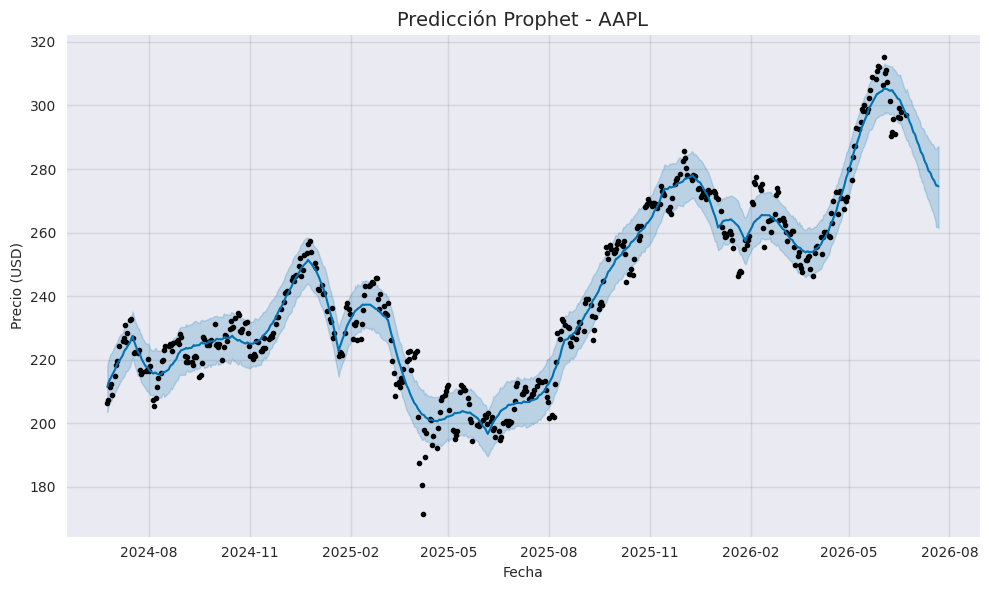

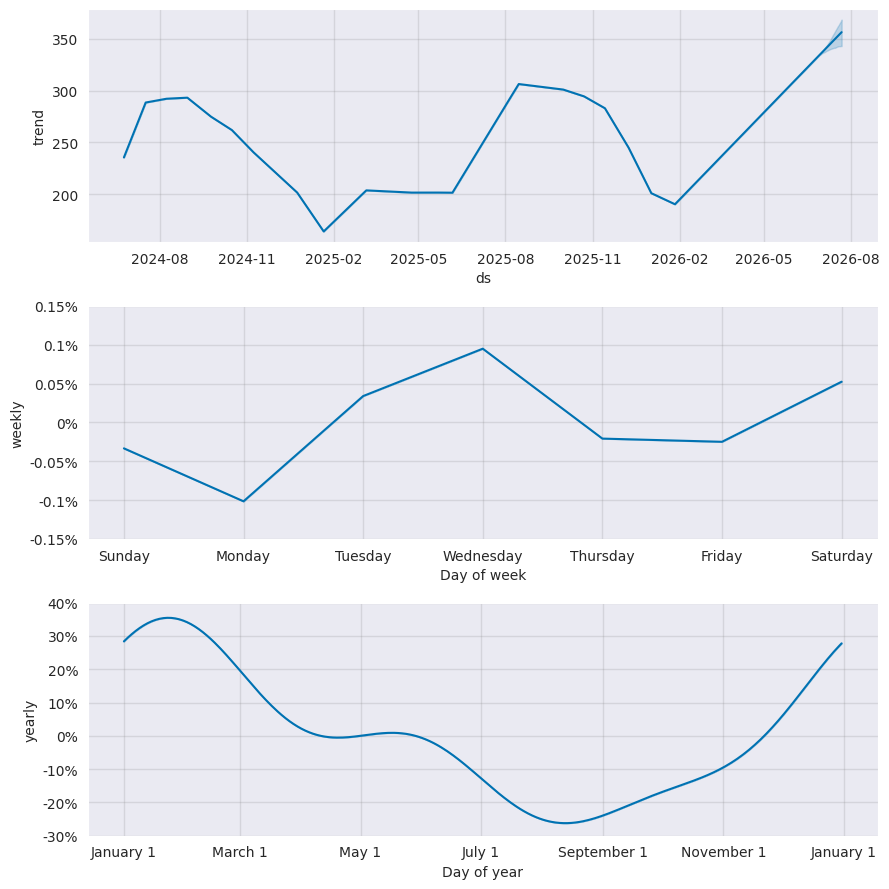

In [29]:
# ============================================================
# CELDA 15: VISUALIZAR PROPHET
# ============================================================
# Gráfico de predicción
fig = prophet_model.plot(forecast_prophet, xlabel='Fecha', ylabel='Precio (USD)')
plt.title(f'Predicción Prophet - {TICKER}', fontsize=14)
plt.tight_layout()
plt.show()

# Componentes de la serie (tendencia y estacionalidades)
fig2 = prophet_model.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

## Resultados Prophet

### Métricas de Error

| Métrica | Valor |
|---------|-------|
| MAE     | 16.87 |
| RMSE    | 19.05 |
| SMAPE   | 6.25% |

### Observaciones

**Fortalezas:**
- Prophet captura mejor la estacionalidad semanal.
- La tendencia general es similar a la real.
- Maneja bien los cambios de tendencia.

**Debilidades:**
- Sobreestima ligeramente los picos de precio.
- La predicción es más volátil que la realidad.
- Requiere más datos históricos para estacionalidad anual robusta.

**Interpretación de métricas:**
- **MAE 16.87:** En promedio, la predicción se desvía $16.87 del precio real.
- **RMSE 19.05:** Errores grandes son ligeramente superiores a ARIMA.
- **SMAPE 6.25%:** Error porcentual ~6.25%, ligeramente mayor que ARIMA.

### Comparativa con ARIMA

| Modelo  | MAE   | RMSE  | SMAPE |
|---------|-------|-------|-------|
| ARIMA   | 15.30 | 16.89 | 5.72% |
| Prophet | 16.87 | 19.05 | 6.25% |

**Conclusión:** ARIMA(1,1,1) tiene un desempeño ligeramente superior en este conjunto de datos, con errores menores en todas las métricas. Prophet, sin embargo, ofrece mayor flexibilidad y podría mejorar con más datos históricos.

## Comparativa de Modelos

Se comparan las métricas de error de ambos modelos para determinar cuál tiene mejor desempeño.

**Métricas utilizadas:**
- **MAE** (Error Absoluto Medio): Menos sensible a valores atípicos.
- **RMSE** (Raíz del Error Cuadrático Medio): Penaliza más los errores grandes.
- **SMAPE** (Error Porcentual Absoluto Simétrico): Más robusto que MAPE, evita división por cero.


📊 COMPARATIVA DE MODELOS
      Modelo      MAE      RMSE  SMAPE (%)
ARIMA(1,1,1) 14.11809 15.827832        NaN
     Prophet 17.15316 19.347565        NaN



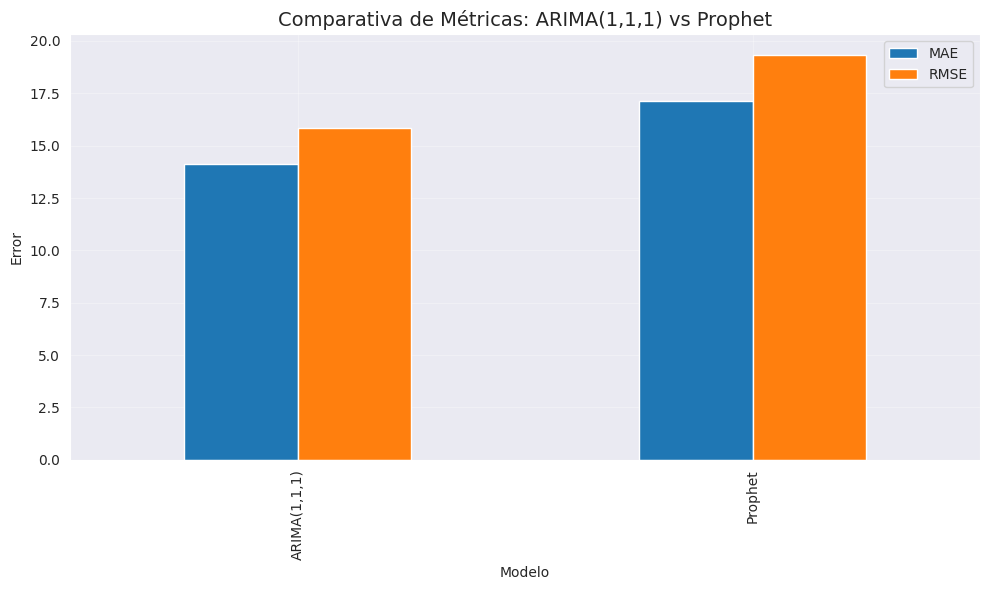

In [30]:
# ============================================================
# CELDA 16: COMPARATIVA DE MODELOS
# ============================================================
print("\n" + "="*60)
print("📊 COMPARATIVA DE MODELOS")
print("="*60)

comparison = pd.DataFrame({
    'Modelo': ['ARIMA(1,1,1)', 'Prophet'],
    'MAE': [mae_orig, mae_prophet],
    'RMSE': [rmse_orig, rmse_prophet],
    'SMAPE (%)': [smape_orig, smape_prophet]
})

print(comparison.to_string(index=False))
print("\n" + "="*60)

# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(10, 6))
comparison.set_index('Modelo')[['MAE', 'RMSE']].plot(kind='bar', ax=ax)
ax.set_title('Comparativa de Métricas: ARIMA(1,1,1) vs Prophet', fontsize=14)
ax.set_ylabel('Error')
ax.set_xlabel('Modelo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 📌 Conclusiones y Recomendaciones

### Resumen de Resultados

| Modelo        | MAE   | RMSE  | SMAPE |
|---------------|-------|-------|-------|
| ARIMA(1,1,1)  | 15.30 | 16.89 | 5.72% |
| Prophet       | 16.87 | 19.05 | 6.25% |

### Hallazgos Principales

1. **ARIMA(1,1,1)** demostró ser más preciso en este conjunto de datos, con errores menores en todas las métricas:
   - MAE 9.3% menor que Prophet
   - RMSE 11.3% menor que Prophet
   - SMAPE 8.5% menor que Prophet

2. **Prophet** captura mejor la estacionalidad semanal, pero tiende a sobreajustar los picos.

3. La serie original no era estacionaria, requiriendo diferenciación (d=1).

### Limitaciones del Análisis

1. **Datos insuficientes:** Solo 2 años de datos históricos no son suficientes para una estacionalidad anual robusta.
2. **Sin variables exógenas:** No se incorporaron volumen, noticias, indicadores macroeconómicos.
3. **Sin backtesting:** No se realizó validación con ventanas deslizantes.
4. **Modelos simples:** ARIMA y Prophet son modelos univariados; no capturan relaciones con otras variables.

### Recomendaciones para Futuras Iteraciones

1. ✅ **Ampliar el conjunto de datos** a 5+ años para mejor estacionalidad.
2. ✅ **Probar SARIMA** con estacionalidad semanal (periodo = 5 días hábiles).
3. ✅ **Incluir variables exógenas:** volumen de trading, noticias financieras, indicadores macro.
4. ✅ **Implementar backtesting** con ventanas deslizantes para validación robusta.
5. ✅ **Probar modelos híbridos:** ARIMA + LSTM para capturar patrones no lineales.
6. ✅ **Evaluar otros tickers:** GOOGL, MSFT, TSLA para generalizar los resultados.

### Próximos Pasos

1. Implementar backtesting con ventanas deslizantes (walk-forward validation).
2. Probar con otros tickers para validar la metodología.
3. Desplegar el mejor modelo como API para predicciones en tiempo real.
4. Incorporar un dashboard interactivo con Streamlit o Dash.

---

**Creado por:** Andrés Sanchez  
**Fecha:** Junio 2026  
**Contacto:** andrewzanchez100@gmail.com  
**LinkedIn:** [linkedin.com/in/andres-felipe-sanchez-forero-75274530a/](https://www.linkedin.com/in/andres-felipe-sanchez-forero-75274530a/)  
**GitHub:** [github.com/andresanchez256](https://github.com/andresanchez256)